Imports and Data Acquisition

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

# Load dataset
raw_data_path = r"D:\insurance (1).csv"
insurance_records = pd.read_csv(raw_data_path)


Data Cleaning and Integrity

In [7]:
# Handle missing values
print("Missing values per category:")
print(insurance_records.isnull().sum()) 

# Duplicate values
duplicate_count = insurance_records.duplicated().sum()
if duplicate_count > 0:
    insurance_records = insurance_records.drop_duplicates()
print(f"Dataset shape after cleaning: {insurance_records.shape}")

Missing values per category:
age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64
Dataset shape after cleaning: (1337, 9)


Outlier Detection and Visualization

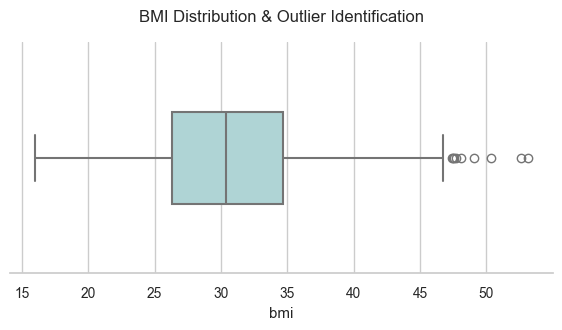

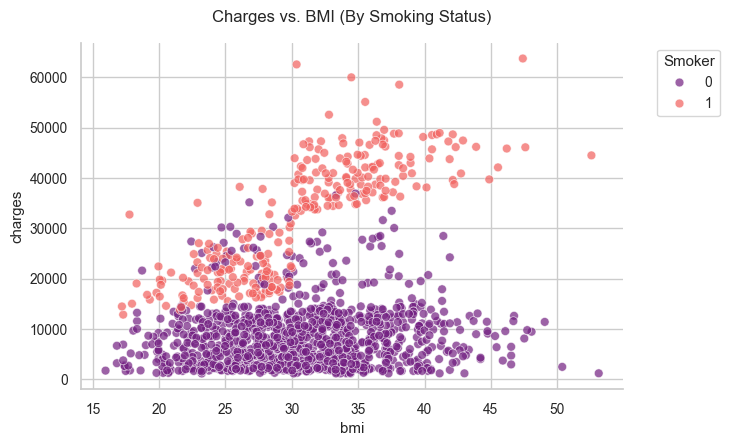

C:\Users\udhay\AppData\Local\Temp\ipykernel_17744\3334698945.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=insurance_records, palette='pastel', edgecolor=".6")


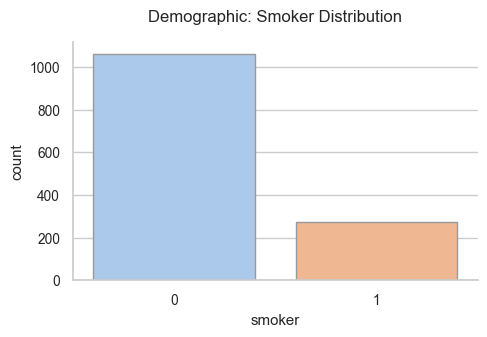

In [8]:

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=0.9) 

# 1. Outlier Detection (Reduced Size)
plt.figure(figsize=(7, 3)) 
sns.boxplot(x=insurance_records['bmi'], color='#A8DADC', width=0.4, linewidth=1.5)
sns.despine(left=True) # Removes the box border for a modern look
plt.title('BMI Distribution & Outlier Identification', fontsize=12, pad=15)
plt.show()

# 2. BMI vs Charges 
plt.figure(figsize=(7, 4.5)) 
sns.scatterplot(data=insurance_records, x='bmi', y='charges', 
                hue='smoker', palette='magma', alpha=0.7, s=40)
sns.despine()
plt.title('Charges vs. BMI (By Smoking Status)', fontsize=12, pad=15)
plt.legend(title='Smoker', bbox_to_anchor=(1.05, 1), loc='upper left') # Legend outside
plt.show()

# 3. Smokers Count 
plt.figure(figsize=(5, 3.5)) 
sns.countplot(x='smoker', data=insurance_records, palette='pastel', edgecolor=".6")
sns.despine()
plt.title('Demographic: Smoker Distribution', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

OUTLIER ANALYSIS & REMEDIATION

--- PRE-HANDLING STATS ---
Outliers Identified: 9
Maximum BMI: 53.13

--- POST-HANDLING STATS ---
Remaining Outliers: 0
New Maximum BMI: 47.32


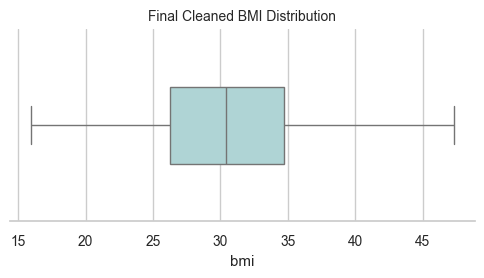

In [9]:


#  Identify Boundaries
Q1 = insurance_records['bmi'].quantile(0.25)
Q3 = insurance_records['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Comparison (before)
pre_count = ((insurance_records['bmi'] < lower_limit) | (insurance_records['bmi'] > upper_limit)).sum()
print(f"--- PRE-HANDLING STATS ---")
print(f"Outliers Identified: {pre_count}")
print(f"Maximum BMI: {insurance_records['bmi'].max():.2f}")

# Apply Capping 
insurance_records['bmi'] = np.where(insurance_records['bmi'] > upper_limit, upper_limit, 
                           np.where(insurance_records['bmi'] < lower_limit, lower_limit, insurance_records['bmi']))

# Comparison: (after)
post_count = ((insurance_records['bmi'] < lower_limit) | (insurance_records['bmi'] > upper_limit)).sum()
print(f"\n--- POST-HANDLING STATS ---")
print(f"Remaining Outliers: {post_count}")
print(f"New Maximum BMI: {insurance_records['bmi'].max():.2f}")

plt.figure(figsize=(6, 2.5))
sns.boxplot(x=insurance_records['bmi'], color='#A8DADC', width=0.4)
sns.despine(left=True)
plt.title('Final Cleaned BMI Distribution', fontsize=10)
plt.show()

Data Preprocessing and Engineering

In [11]:

# Encoding Categorical Data
binary_encoder = LabelEncoder()
# We use the records where outliers were already capped
insurance_records['sex'] = binary_encoder.fit_transform(insurance_records['sex'])
insurance_records['smoker'] = binary_encoder.fit_transform(insurance_records['smoker'])

# One-Hot Encoding for Region
if 'region' in insurance_records.columns:
    insurance_records = pd.get_dummies(insurance_records, columns=['region'], drop_first=True)
    print("Successfully encoded 'region'.")
else:
    print("Notice: 'region' already encoded. Skipping to avoid error.")

# Feature Selection
# Separating the 'target' (what we want to predict) from 'features' (the inputs)
X_features = insurance_records.drop('charges', axis=1)
y_target = insurance_records['charges']

# Data Splitting (80% Training, 20% Testing)
x_train, x_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)

# Feature Scaling
standard_scaler = StandardScaler()
x_train_scaled = standard_scaler.fit_transform(x_train)
x_test_scaled = standard_scaler.transform(x_test)

print("Preprocessing complete. Data is scaled and ready for XGBoost.")

Notice: 'region' already encoded. Skipping to avoid error.
Preprocessing complete. Data is scaled and ready for XGBoost.


Model Training and Export

In [ ]:
# Train ML Model
actuarial_engine = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=42)
actuarial_engine.fit(x_train_scaled, y_train)
final_predictions = actuarial_engine.predict(x_test_scaled)
print(f"Model Accuracy (R2 Score): {r2_score(y_test, final_predictions)*100:.2f}%")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, final_predictions):.2f}")

joblib.dump(actuarial_engine, 'medical_model.pkl')
joblib.dump(standard_scaler, 'scaler.pkl')
joblib.dump(X_features.columns.tolist(), 'features.pkl')

--- RANDOM FOREST PERFORMANCE ---
Model Accuracy (R2): 88.11%
Average Prediction Error: $2630.31


['medical_model.pkl']